# Lab 3 — Dữ liệu và Wavelet Hashing
**Sinh viên: Trần Ngọc Nhân** · Phụ trách **Phase 1 và Phase 2**.

Notebook trình bày dữ liệu, biến dạng, DWT 2D, wHash 64/256 bit và Hamming.
Đánh giá ROC, chọn ngưỡng và benchmark thuộc phần Thanh Nguyên; Web Studio thuộc Minh Quân.
Kết quả trong notebook được tính từ mã nguồn, không điền số liệu thủ công.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import matplotlib.pyplot as plt
import pywt
from PIL import Image

# Hỗ trợ mở notebook từ lab3, thư mục dự án hoặc thư mục chứa dự án.
ROOT = next(p.resolve() for p in [Path.cwd(), Path.cwd() / 'lab3',
    Path.cwd() / 'Computer_Vision_Lab-main/lab3'] if (p / 'vision_wavelet.py').exists())
sys.path.insert(0, str(ROOT))
from vision_wavelet import (WaveletHasher, build_dataset, compute_pair_distances,
    hamming_distance, similarity_percentage, hash_to_hex)
DATA, OUT = ROOT / 'data', ROOT / 'results'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print('NumPy:', np.__version__, '| PyWavelets:', pywt.__version__)


NumPy: 2.5.3 | PyWavelets: 1.8.0


## 1. Chuẩn bị dữ liệu — các mục 1.1–1.5

Dùng 10 ảnh mẫu từ `scikit-image` và 5 chữ số bảy đoạn tự vẽ: tổng cộng 15 ảnh nguồn.
Đây là bộ dữ liệu minh họa nhỏ, có cả ảnh tổng hợp; không đại diện cho ảnh chụp ở góc nhìn khác.
Mỗi nguồn có 15 biến thể: xoay ±5°/±10°, resize 0.8/1.2, sáng 0.8/1.2,
Gauss σ=10, muối tiêu 2%, JPEG 30/50/70, blur 1.5, crop 5% mỗi phía.
Xoay giữ nguyên khung, phần trống nền trắng; resize thay đổi độ phân giải, không mô phỏng zoom camera.

Cặp dương: ảnh gốc và biến thể cùng nguồn. Cặp âm: mỗi tổ hợp hai nguồn khác nhau một lần.
Nhãn dựa trên nguồn gốc ảnh, không được suy ra từ khoảng cách hash.


Ảnh gốc: 15; cặp tương tự: 225; cặp khác biệt: 105


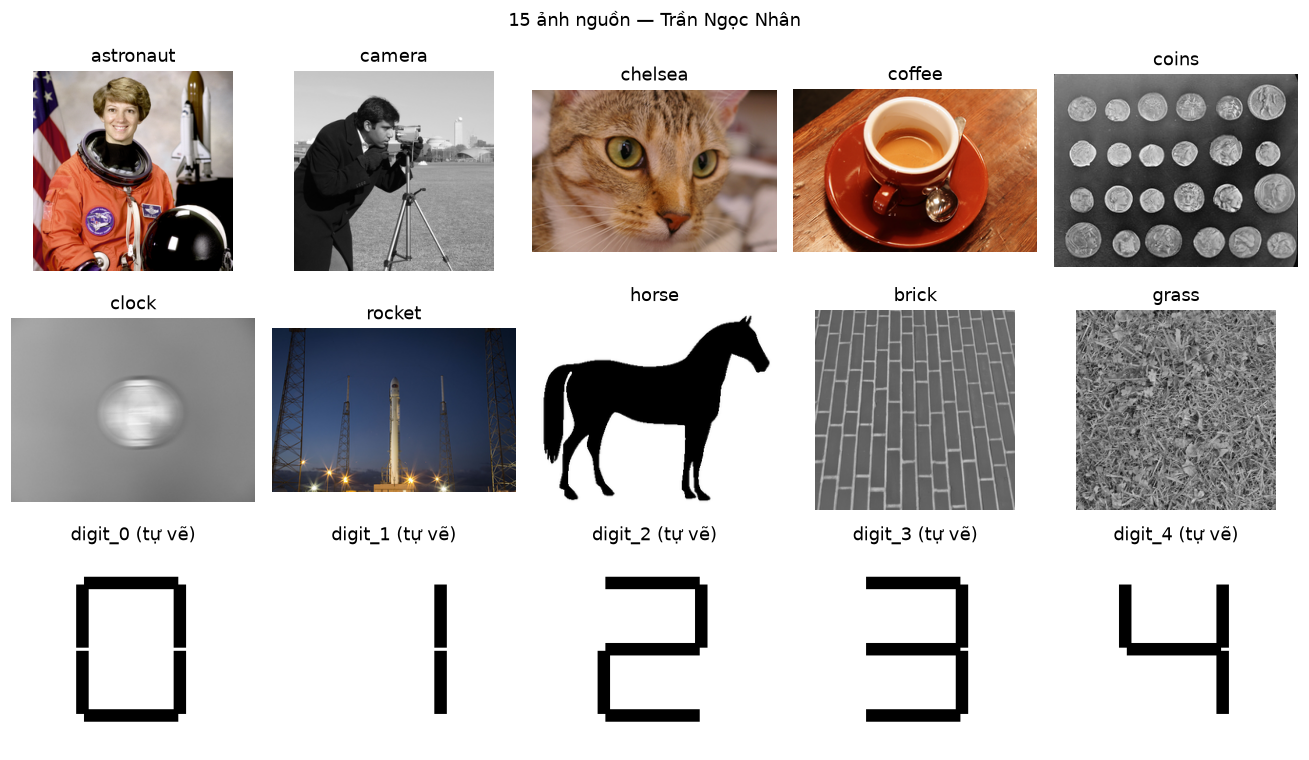

In [2]:
if not (DATA / 'dataset_pairs.json').exists():
    build_dataset(DATA, seed=42)
manifest = json.loads((DATA / 'dataset_pairs.json').read_text(encoding='utf-8'))
positives = sum(p['label'] for p in manifest['pairs'])
print(f"Ảnh gốc: {len(manifest['originals'])}; cặp tương tự: {positives}; "
      f"cặp khác biệt: {len(manifest['pairs']) - positives}")
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for ax, item in zip(axes.flat, manifest['originals']):
    with Image.open(DATA / item['path']) as im:
        ax.imshow(im)
    ax.set_title(item['id'] + (' (tự vẽ)' if item['synthetic'] else ''))
    ax.axis('off')
fig.suptitle('15 ảnh nguồn — Trần Ngọc Nhân')
fig.tight_layout()
fig.savefig(OUT / 'originals.png', bbox_inches='tight')
plt.show()


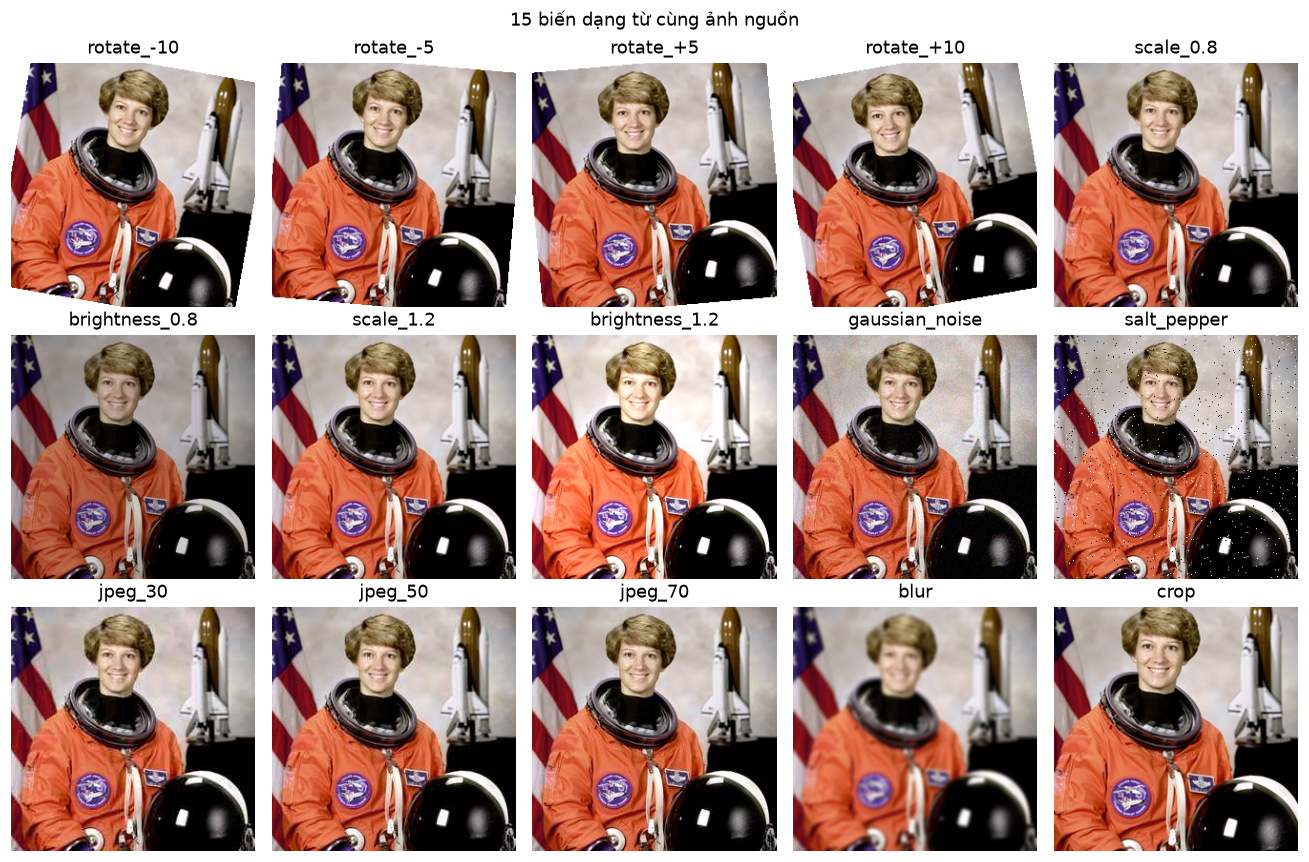

{
  "image1": "original/astronaut.png",
  "image2": "augmented_similar/astronaut__rotate_-10.png",
  "label": 1,
  "source_id1": "astronaut",
  "source_id2": "astronaut",
  "transform": "rotate_-10",
  "parameters": {
    "angle": -10
  },
  "id": "pair_0000"
}


In [3]:
examples = [p for p in manifest['pairs'] if p['source_id1'] == 'astronaut' and p['label'] == 1]
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, pair in zip(axes.flat, examples):
    with Image.open(DATA / pair['image2']) as im:
        ax.imshow(im)
    ax.set_title(pair['transform'])
    ax.axis('off')
fig.suptitle('15 biến dạng từ cùng ảnh nguồn')
fig.tight_layout()
fig.savefig(OUT / 'augmentations.png', bbox_inches='tight')
plt.show()
print(json.dumps(examples[0], ensure_ascii=False, indent=2))


## 2. Tiền xử lý và DWT — các mục 2.1–2.2

Ảnh được sửa hướng EXIF, ghép alpha lên nền trắng, chuyển xám, resize 32×32,
đưa về [0,1]. Haar level 2 với `periodization` cho LL kích thước 8×8.
`wavedec2` trả `[cA_n, (cH_n,cV_n,cD_n), ..., (cH_1,cV_1,cD_1)]`.
Ở đây hiển thị **bốn băng cùng cấp sâu nhất**: LL=cA, LH=cH, HL=cV, HH=cD.
Tên hướng ngang/dọc tuân theo trục của PyWavelets.

Nguồn: [PyWavelets — DWT 2D](https://pywavelets.readthedocs.io/en/latest/ref/2d-dwt-and-idwt.html).


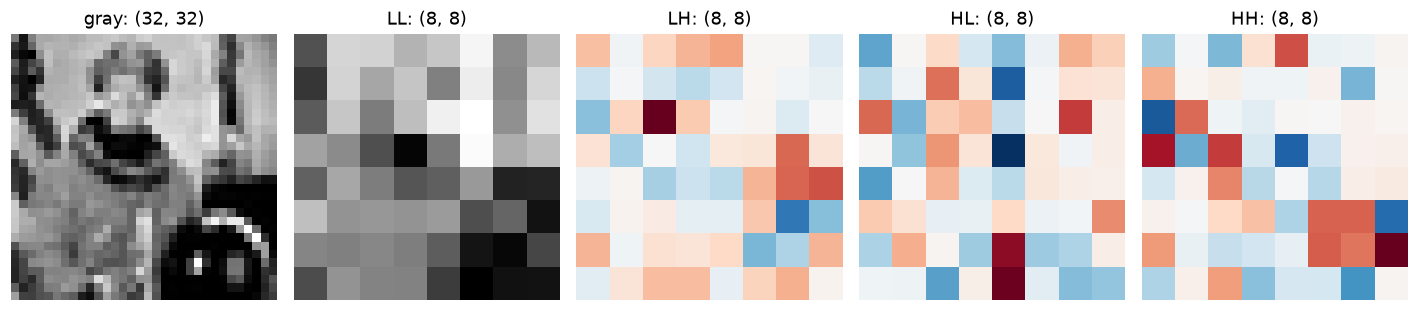

Sai số tái dựng lớn nhất: 7.771561172376096e-16


In [4]:
hasher = WaveletHasher(hash_size=8, image_size=32, wavelet='haar', level=2)
sample = DATA / 'original/astronaut.png'
analysis = hasher.analyze(sample)
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax, key in zip(axes, ['gray', 'LL', 'LH', 'HL', 'HH']):
    matrix = analysis[key]
    limit = max(float(np.abs(matrix).max()), 1e-12)
    if key in ('LH', 'HL', 'HH'):
        ax.imshow(matrix, cmap='RdBu_r', vmin=-limit, vmax=limit)
    else:
        ax.imshow(matrix, cmap='gray')
    ax.set_title(f'{key}: {matrix.shape}')
    ax.axis('off')
fig.tight_layout()
fig.savefig(OUT / 'subbands.png', bbox_inches='tight')
plt.show()
restored = pywt.waverec2(analysis['coeffs'], 'haar', mode='periodization')
print('Sai số tái dựng lớn nhất:', np.max(np.abs(restored - analysis['gray'])))


## 3. Lượng tử hóa và sinh wHash — các mục 2.3 và 2.5

Bit = 1 nếu hệ số **≥ ngưỡng median/mean**, ngược lại bằng 0. Đọc theo từng hàng.
Với LL lớn hơn kích thước hash, lấy trung bình các khối đều nhau; LL nhỏ hơn bị từ chối.
Để có 256 bit dùng ảnh 64×64, Haar level 2 → LL 16×16.
Cấu hình được lưu cùng hash. Không so sánh hash tạo bằng các cấu hình khác nhau.
Đây là biến thể wHash theo đề bài, không cam kết trùng thư viện ImageHash.


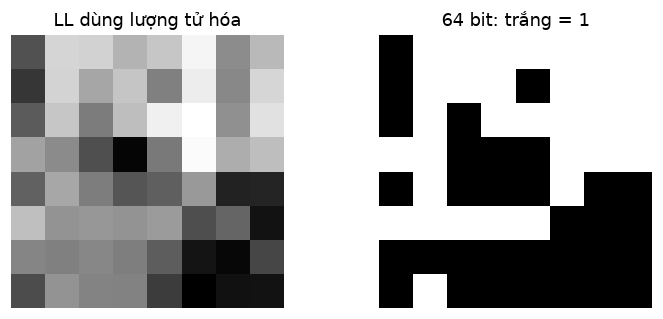

Ngưỡng: 1.8529411764705888
Nhị phân: 0111111101110111010111111100011101000100111110000000000001000000
Hex 64 bit: 7f775fc744f80040
median: 256 bit, hex = 7ffb3d7b3b773f7b3ffb92fb907f707378303c20ee80e584e580608035000480
mean: 256 bit, hex = 7ffb3d7b3b773f7b3ffb93fbd87f707378307c60ffc0efc4ed8268803f001480


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(analysis['features'], cmap='gray')
axes[0].set_title('LL dùng lượng tử hóa')
axes[1].imshow(analysis['bits'].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('64 bit: trắng = 1')
for ax in axes:
    ax.axis('off')
fig.tight_layout()
fig.savefig(OUT / 'hash_bits.png', bbox_inches='tight')
plt.show()
print('Ngưỡng:', analysis['cutoff'])
print('Nhị phân:', ''.join(analysis['bits'].astype(np.uint8).astype(str)))
print('Hex 64 bit:', analysis['hex'])
for method in ('median', 'mean'):
    large = WaveletHasher(16, 64, threshold=method)
    bits = large.hash(sample)
    print(f'{method}: {len(bits)} bit, hex = {hash_to_hex(bits)}')


## 4. Khoảng cách Hamming — mục 2.4

$D_H$ là số bit lệch; $S=100(1-D_H/N)$ là phần trăm bit trùng nhau,
**không phải xác suất hai ảnh cùng đối tượng**. Chưa đưa ra nhãn dự đoán vì ngưỡng
phải được chọn và kiểm chứng ở Phase 3.


In [6]:
print(f"{'Biến dạng':<22} {'Hamming':>8} {'Bit trùng (%)':>15}")
for pair in examples:
    comparison = hasher.compare(DATA / pair['image1'], DATA / pair['image2'])
    print(f"{pair['transform']:<22} {comparison['distance']:>8} {comparison['similarity']:>15.2f}")
print('So với ảnh coffee:', hasher.compare(sample, DATA / 'original/coffee.png'))
assert hamming_distance('0101', '0011') == 2
assert similarity_percentage('0101', '0011') == 50


Biến dạng               Hamming   Bit trùng (%)
rotate_-10                   14           78.12
rotate_-5                    10           84.38
rotate_+5                    10           84.38
rotate_+10                   18           71.88
scale_0.8                     0          100.00
brightness_0.8                0          100.00
scale_1.2                     0          100.00
brightness_1.2                2           96.88
gaussian_noise                0          100.00
salt_pepper                   0          100.00
jpeg_30                       0          100.00
jpeg_50                       0          100.00
jpeg_70                       0          100.00
blur                          0          100.00
crop                          4           93.75
So với ảnh coffee: {'distance': 20, 'similarity': 68.75}


## 5. Bàn giao cho Phase 3 và giới hạn

Xuất hash và khoảng cách cho toàn bộ cặp ảnh để Thanh Nguyên dùng đánh giá.
Các cặp không độc lập vì dùng chung ảnh nguồn. Khi chia tập chọn ngưỡng/kiểm thử,
**chia theo `source_id` trước**, rồi tạo/lọc cặp chỉ chứa nguồn trong cùng tập;
không chia ngẫu nhiên từng cặp gây rò rỉ dữ liệu. Cặp âm có hai nguồn nên phải kiểm tra cả hai.

Ảnh đơn sắc có thể trùng hash; ảnh khác nhau cũng có thể va chạm hash.
wHash không bất biến hoàn toàn với xoay, crop hay góc chụp. Các chữ số cùng nền trắng
có thể gần nhau về hash dù khác nguồn. Bộ dữ liệu 15 nguồn chỉ phù hợp kiểm tra pipeline.


In [7]:
result = compute_pair_distances(DATA, hasher)
(OUT / 'pair_distances.json').write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
for label, name in [(1, 'Cùng nguồn'), (0, 'Khác nguồn')]:
    values = np.array([p['distance'] for p in result['pairs'] if p['label'] == label])
    print(f'{name}: n={values.size}, min={values.min()}, trung bình={values.mean():.2f}, max={values.max()}')
print('Đã lưu:', OUT / 'pair_distances.json')


Cùng nguồn: n=225, min=0, trung bình=4.64, max=28
Khác nguồn: n=105, min=8, trung bình=31.03, max=52
Đã lưu: C:\Users\nhan3\Downloads\Computer_Vision_Lab-main (2)\Computer_Vision_Lab-main\lab3\results\pair_distances.json


## 6. Kiểm thử

Chạy `python -m unittest -v test_vision_wavelet.py` tại thư mục lab3.
Đối chứng gồm Haar với ma trận biết trước, tái dựng nghịch đảo trên 6 họ wavelet,
64/256 bit, median/mean, Hamming, alpha, ảnh đơn sắc, tham số sai,
tái lập nhiễu và kiểm tra mọi cặp/ảnh trong chỉ mục.

Nguồn ảnh và mô tả: [scikit-image data](https://scikit-image.org/docs/stable/api/skimage.data.html),
chi tiết từng ảnh được lưu trong `dataset_pairs.json`.
